In [3]:
from scipy.interpolate import interp1d
from lookup_table import lookup_table as lookup_table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ImportError: cannot import name 'lookup_table' from 'lookup_table' (c:\Users\Mark\serpentine_alteration\lookup_table.py)

In [ ]:
lookup_table.head()

,T,wCO2,rho_s,rho_fl,mu_fl,wC_s,wC_fl,wSi_s,wH_s,wMg_s,wCO2_fl,wCO2_s,wSiO2_s,wH2O_s
0,298.15,0,2639.990543,992.125075,-230665.505944,0.000000,0.0,0.201954,0.013352,0.227319,0.0,0.000000,0.131773,0.000747
1,298.15,3,2664.957878,992.125075,-230665.505944,0.008622,0.0,0.197291,0.012092,0.222071,0.0,0.002353,0.128730,0.000676
2,298.15,6,2688.095956,992.125075,-230665.505944,0.016852,0.0,0.192810,0.010904,0.217027,0.0,0.004599,0.125807,0.000610
3,298.15,9,2688.095956,992.125075,-230665.505944,0.016852,0.0,0.192810,0.010904,0.217027,0.0,0.004599,0.125807,0.000610
4,298.15,12,2732.409032,992.125075,-230665.505944,0.032240,0.0,0.184433,0.008683,0.207597,0.0,0.008799,0.120340,0.000486


GENERAL DATA

In [ ]:
T_STEPS, WCO2_STEPS = lookup_table['T'].unique(), lookup_table['wCO2'].unique()
EXTENT_SYS = [lookup_table['wCO2'].min(), lookup_table['wCO2'].max(), T_STEPS.min(), T_STEPS.max()]
EXTENT_FL = [lookup_table['wCO2_fl'].min(), lookup_table['wCO2_fl'].max(), T_STEPS.min(), T_STEPS.max()]
WCO2_FL_AXES = np.linspace(0, lookup_table['wCO2_fl'].max(), 100)

T_MIN, T_MAX = lookup_table['T'].min(), lookup_table['T'].max()
WCO2_MIN, WCO2_MAX = lookup_table['wCO2'].min(), lookup_table['wCO2'].max()
WCO2_FL_MIN, WCO2_FL_MAX = lookup_table['wCO2_fl'].min(), lookup_table['wCO2_fl'].max()

In [ ]:
def plot_wCO2_sys(key, title, colorbar_unit = '% [kg/kg]'):
    data = []
    for T in T_STEPS:
        data.append([lookup_table[(lookup_table['T'] == T) & (lookup_table['wCO2'] == CO2)][key].values[0] for CO2 in WCO2_STEPS]) 

    fig, ax = plt.subplots()
    im = ax.imshow(data, extent=EXTENT_SYS,origin='lower', aspect='auto')
    fig.colorbar(im, ax=ax, label= f'{key} {colorbar_unit}')
    ax.set_title(f'{title} - {key}')

    ax.invert_yaxis()
    ax.set_ylim(bottom=T_MIN, top=T_MAX)
    ax.set_ylabel('Temperature [K]')

    ax.set_xlim(left=lookup_table['wCO2'].min(), right=lookup_table['wCO2'].max())
    ax.set_xlabel('% CO2 sys [kg/kg]')

    plt.show() 

    fig.savefig(f'{title}_wCO2')


In [ ]:
def plot_wCO2_fluid(key: str, title: str, colorbar_unit: str = '% [kg/kg]'):
    data = []
    for T in T_STEPS:
        #sort that the wCO2_fl values are ascending
        row: pd.DataFrame = lookup_table[lookup_table['T'] == T]
        row = row.sort_values(by='wCO2_fl')

        x_vals, y_vals = row['wCO2_fl'].values, row[key].values

        # interpolate onto new grid
        f_interp = interp1d(x_vals, y_vals, kind='nearest', fill_value='extrapolate', assume_sorted=True)

        interpolated_weights = f_interp(WCO2_FL_AXES)  # Interpolate to common x-values
        data.append(interpolated_weights)

    fig, ax = plt.subplots()
    im = ax.imshow(data, extent=EXTENT_FL, origin='lower', aspect='auto')

    fig.colorbar(im, ax=ax, label= f'{key} {colorbar_unit}')

    ax.set_title(f'{title} - {key}')

    ax.invert_yaxis()
    ax.set_ylim(bottom=T_MIN, top=T_MAX)
    ax.set_ylabel('Temperature [K]')

    ax.set_xlim(left=WCO2_FL_MIN, right=WCO2_FL_MAX)
    ax.set_xlabel('% CO2 in fluid [kg/kg]')

    plt.show()

    fig.savefig(f'{title}_wCO2_fl')


PLOTTING

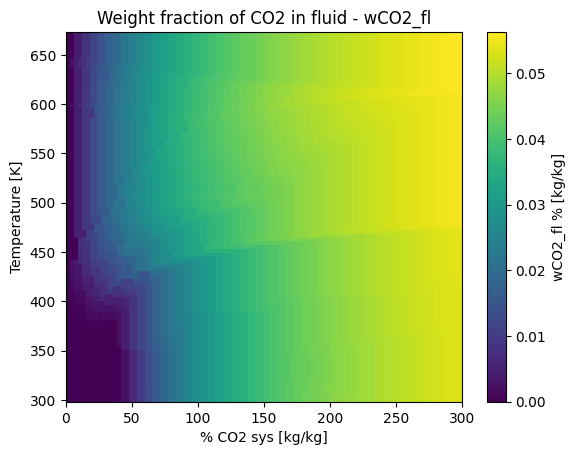

In [13]:
plot_wCO2_sys('wCO2_fl', 'Weight fraction of CO2 in fluid')

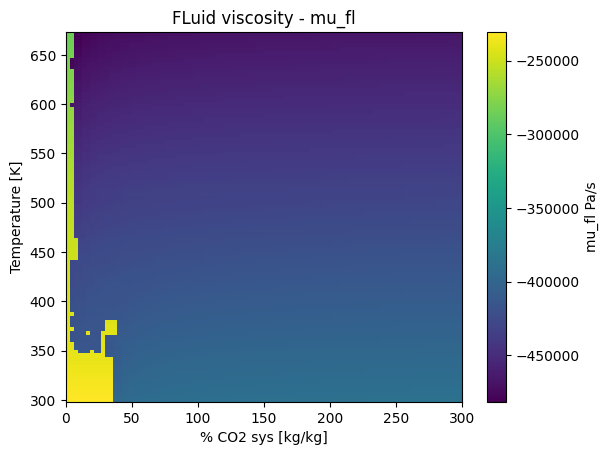

In [14]:
plot_wCO2_sys('mu_fl', 'FLuid viscosity','Pa/s')

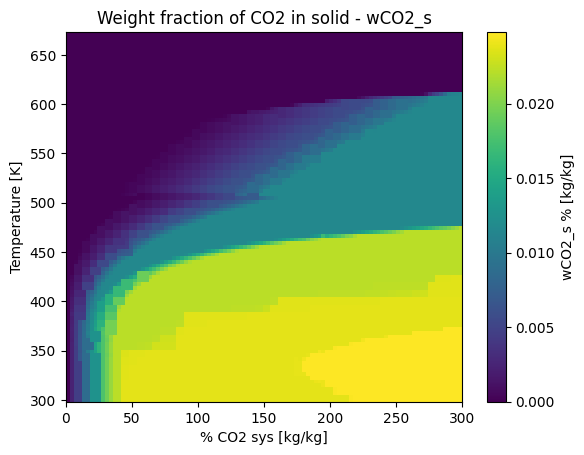

In [15]:
plot_wCO2_sys('wCO2_s', 'Weight fraction of CO2 in solid')

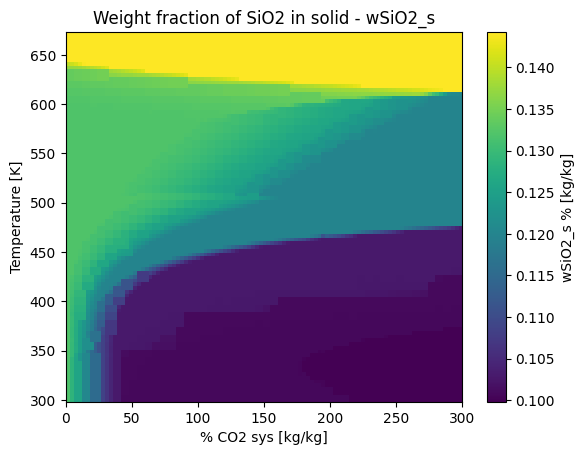

In [16]:
plot_wCO2_sys('wSiO2_s', 'Weight fraction of SiO2 in solid')
 

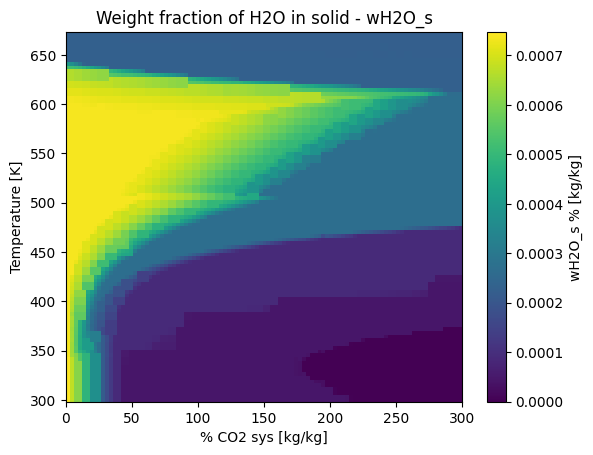

In [17]:
plot_wCO2_sys('wH2O_s', 'Weight fraction of H2O in solid')
 

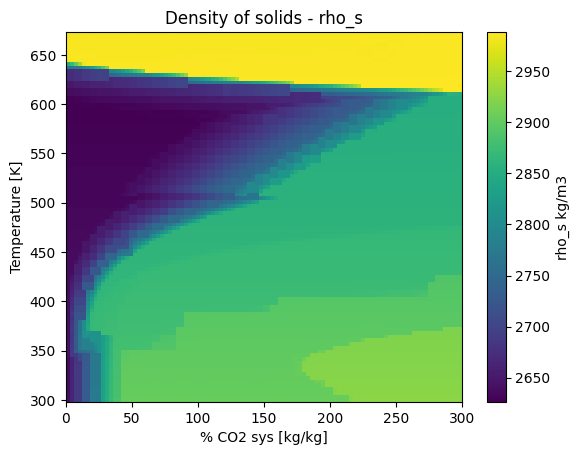

In [18]:
plot_wCO2_sys('rho_s', 'Density of solids','kg/m3')
 

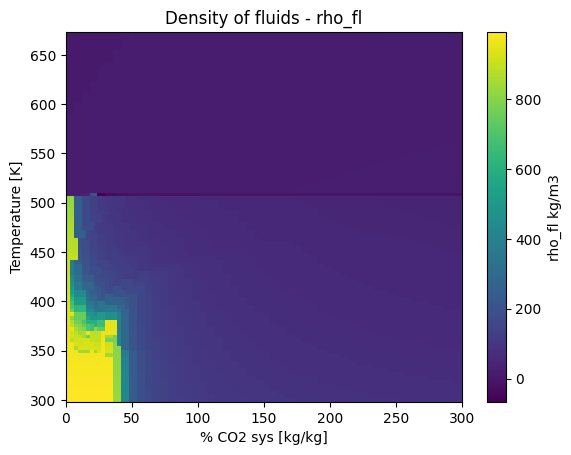

In [19]:
plot_wCO2_sys('rho_fl', 'Density of fluids','kg/m3')

PLOTTING FOR CO2 - fluid

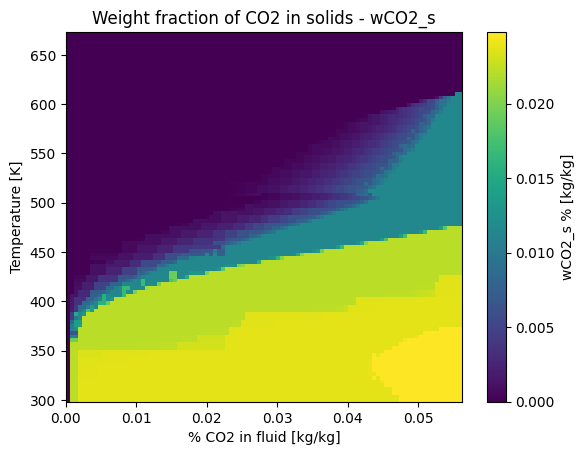

In [20]:
plot_wCO2_fluid('wCO2_s', 'Weight fraction of CO2 in solids')

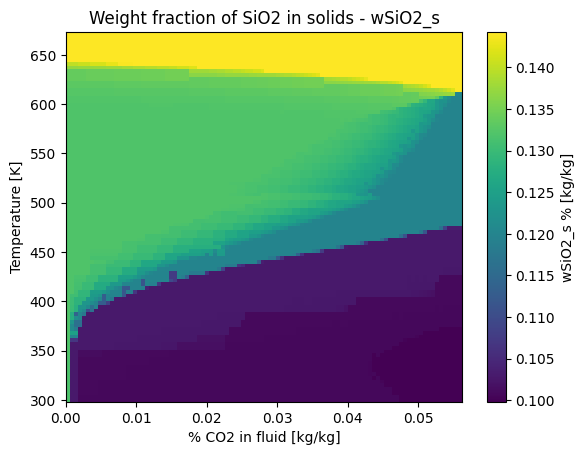

In [21]:
plot_wCO2_fluid('wSiO2_s', 'Weight fraction of SiO2 in solids')

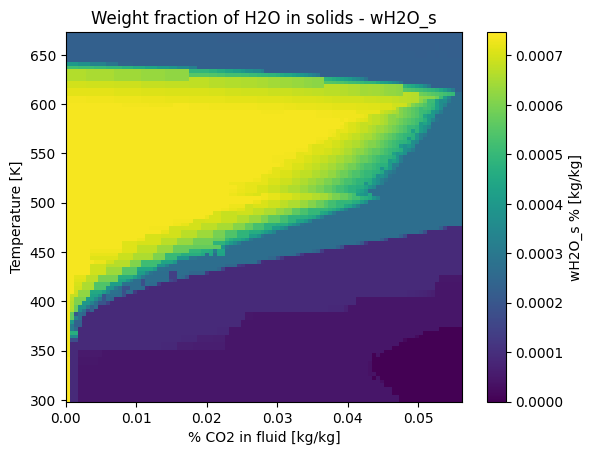

In [22]:
plot_wCO2_fluid('wH2O_s', 'Weight fraction of H2O in solids')

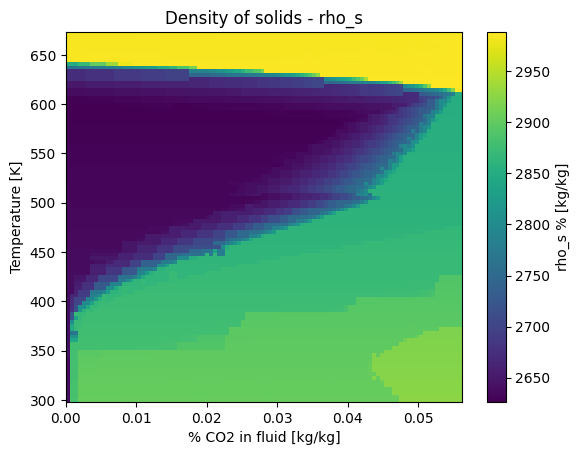

In [23]:
plot_wCO2_fluid('rho_s', 'Density of solids')

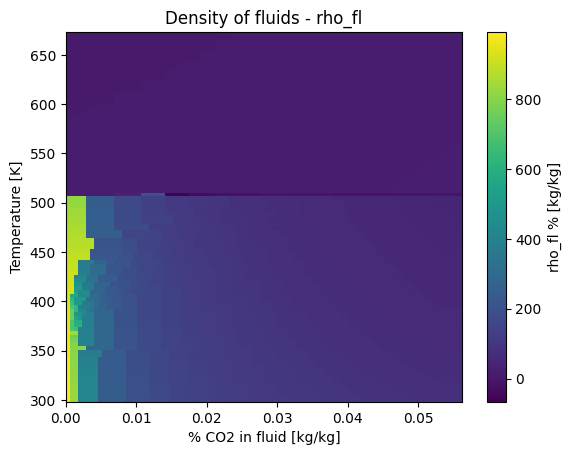

In [24]:
plot_wCO2_fluid('rho_fl', 'Density of fluids')